# E4 — Content patching (causal)

**Plan reference:** Phase 2, experiment E4.

**Question:** Does the residual state at the impulse locus **causally determine** \(W\) preference at \(t^*\)?

**Interventions** (E3-nominated `W_window`, L5–L11):
- **Necessity:** on W-prompt, replace `W_window` `resid_post` with C-counterfactual run.
- **Sufficiency:** on C-prompt, patch in W-run residuals.
- **Write ablation:** zero `attn_out`+`mlp_out` at nominated sites.
- **Controls:** revision, ops2, distance-matched random position.

Primary readout: \(\mathrm{logit}(W)-\mathrm{logit}(C)\) at \(t^*\).


In [1]:
# %pip install tuned-lens transformer-lens torch matplotlib numpy pandas
from pathlib import Path
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformer_lens as tl
from dataclasses import dataclass
from IPython.display import display

torch.set_grad_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


## Core functions


In [2]:
"""E4 — Content patching (causal necessity/sufficiency at nominated loci)."""

from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformer_lens as tl
from tuned_lens.nn import TunedLens, Unembed

torch.set_grad_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    OUT_DIR = Path(__file__).resolve().parent / "E4_outputs"
except NameError:
    OUT_DIR = Path("E4_outputs")
OUT_DIR.mkdir(exist_ok=True)

LANDING_LAYERS = list(range(5, 12))  # L5–L11 per E3
PRIORITY_LAYERS = [9, 10, 11]


@dataclass(frozen=True)
class Item:
    name: str
    a: int
    b: int
    W_str: str
    C_str: str


ITEMS = [
    Item("ops_12+15", 12, 15, " 25", " 27"),
    Item("ops_8+7", 8, 7, " 14", " 15"),
    Item("ops_11+12", 11, 12, " 22", " 23"),
    Item("ops_9+6", 9, 6, " 14", " 15"),
    Item("ops_13+14", 13, 14, " 26", " 27"),
    Item("ops_4+5", 4, 5, " 8", " 9"),
    Item("ops_16+10", 16, 10, " 24", " 26"),
    Item("ops_3+8", 3, 8, " 10", " 11"),
]

CUE = " Wait, let me recompute."


def find_impulse_pos(str_toks: list[str]) -> int:
    """First token after the first '=' (forced-answer slot; W or C)."""
    for i, t in enumerate(str_toks):
        if t == " =":
            return i + 1
    raise ValueError("no ' =' token")


def find_first_W_pos(str_toks: list[str], W_str: str) -> int:
    eq_seen = False
    for i, t in enumerate(str_toks):
        if t == " =":
            eq_seen = True
            continue
        if eq_seen and t == W_str:
            return i
    raise ValueError(f"W token {W_str!r} not found")


def find_t_star(str_toks: list[str]) -> int:
    eq = [i for i, t in enumerate(str_toks) if t == " ="]
    return eq[-1]


def build_W_prompt(item: Item) -> str:
    return f"{item.a} + {item.b} ={item.W_str}.{CUE} {item.a} + {item.b} ="


def build_C_prompt(item: Item) -> str:
    return f"{item.a} + {item.b} ={item.C_str}.{CUE} {item.a} + {item.b} ="


def tag_regions(str_toks: list[str], W_pos: int, t_star: int) -> dict[str, list[int]]:
    eq_positions = [i for i, t in enumerate(str_toks) if t == " ="]
    eq1 = eq_positions[0]
    ops2_pos = list(range(t_star - 3, t_star))
    rev_start = next(j for j, t in enumerate(str_toks) if t == " Wait")
    rev_end = ops2_pos[0] - 1
    revision = list(range(rev_start, rev_end + 1))
    W_window = list(range(max(0, W_pos - 2), min(len(str_toks), W_pos + 3)))
    return {
        "W": [W_pos],
        "W_window": W_window,
        "revision": revision,
        "ops2": ops2_pos,
    }


def score_at_tstar(model, logits, t_star: int, W_id: int, C_id: int) -> float:
    v = logits[0, t_star]
    return float(v[W_id] - v[C_id])


def get_positions(model, item: Item, variant: str = "W") -> tuple[torch.Tensor, list[str], int, int, dict[str, list[int]]]:
    prompt = build_W_prompt(item) if variant == "W" else build_C_prompt(item)
    tokens = model.to_tokens(prompt)
    str_toks = model.to_str_tokens(prompt)
    impulse_pos = find_impulse_pos(str_toks)
    t_star = find_t_star(str_toks)
    regions = tag_regions(str_toks, impulse_pos, t_star)
    return tokens, str_toks, impulse_pos, t_star, regions


def run_baseline(model, tokens, t_star: int, W_id: int, C_id: int) -> float:
    logits = model(tokens)
    return score_at_tstar(model, logits, t_star, W_id, C_id)


def make_resid_patch_hooks(
  source_cache,
  layers: list[int],
  positions: list[int],
) -> list[tuple[str, object]]:
    hooks = []
    for L in layers:
        patch = source_cache[f"blocks.{L}.hook_resid_post"][0, positions, :].clone()

        def hook_fn(activation, hook, pos=positions, p=patch):
            activation[0, pos, :] = p
            return activation

        hooks.append((f"blocks.{L}.hook_resid_post", hook_fn))
    return hooks


def make_write_zero_hooks(layers: list[int], positions: list[int]) -> list[tuple[str, object]]:
    hooks = []

    def zero_hook(activation, hook, pos=positions):
        activation[0, pos, :] = 0
        return activation

    for L in layers:
        hooks.append((f"blocks.{L}.hook_attn_out", zero_hook))
        hooks.append((f"blocks.{L}.hook_mlp_out", zero_hook))
    return hooks


def run_with_hooks(model, tokens, hooks, t_star: int, W_id: int, C_id: int) -> float:
    with model.hooks(hooks):
        logits = model(tokens)
    return score_at_tstar(model, logits, t_star, W_id, C_id)


@dataclass
class PatchResult:
    item: str
    intervention: str
    baseline: float
    patched: float
    delta: float
    frac: float


def run_item_interventions(model, item: Item) -> list[PatchResult]:
    W_id = model.to_single_token(item.W_str)
    C_id = model.to_single_token(item.C_str)

    w_tokens, w_toks, W_pos, t_star, regions = get_positions(model, item, "W")
    c_tokens, c_toks, _, _, _ = get_positions(model, item, "C")

    _, w_cache = model.run_with_cache(w_tokens)
    _, c_cache = model.run_with_cache(c_tokens)

    baseline = run_baseline(model, w_tokens, t_star, W_id, C_id)
    c_baseline = run_baseline(model, c_tokens, t_star, W_id, C_id)

    W_window = regions["W_window"]
    revision = regions["revision"]
    ops2 = regions["ops2"]

    # distance-matched control: mirror W_window around t_star
    width = len(W_window)
    center = t_star - 3
    rand_pos = list(range(max(1, center - width // 2), min(len(w_toks), center - width // 2 + width)))
    rand_pos = [p for p in rand_pos if p != t_star][: len(W_window)]

    results: list[PatchResult] = []

    def record(name: str, patched: float, base: float = baseline):
        d = patched - base
        frac = d / base if abs(base) > 1e-6 else float("nan")
        results.append(PatchResult(item.name, name, base, patched, d, frac))

    # --- Necessity on W-prompt: replace W_window resid with C-run ---
    hooks = make_resid_patch_hooks(c_cache, LANDING_LAYERS, W_window)
    record("necessity_resid_Wwin_L5-11_Cswap", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_resid_patch_hooks(c_cache, PRIORITY_LAYERS, W_window)
    record("necessity_resid_Wwin_L9-11_Cswap", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_resid_patch_hooks(c_cache, LANDING_LAYERS, [W_pos])
    record("necessity_resid_W_only_L5-11_Cswap", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    # --- Sufficiency on C-prompt: patch W-run resid into C-run ---
    hooks = make_resid_patch_hooks(w_cache, LANDING_LAYERS, W_window)
    record("sufficiency_resid_Wwin_L5-11_Wpatch", run_with_hooks(model, c_tokens, hooks, t_star, W_id, C_id), base=c_baseline)

    # --- Write ablation on W-prompt ---
    hooks = make_write_zero_hooks(LANDING_LAYERS, [W_pos])
    record("ablate_writes_W_L5-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_write_zero_hooks(LANDING_LAYERS, W_window)
    record("ablate_writes_Wwin_L5-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_write_zero_hooks(PRIORITY_LAYERS, W_window)
    record("ablate_writes_Wwin_L9-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    # --- Region controls (ablate writes) ---
    hooks = make_write_zero_hooks(LANDING_LAYERS, revision)
    record("ablate_writes_revision_L5-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_write_zero_hooks(LANDING_LAYERS, ops2)
    record("ablate_writes_ops2_L5-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    hooks = make_write_zero_hooks(LANDING_LAYERS, rand_pos)
    record("ablate_writes_randpos_L5-11", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    # --- Per-layer necessity sweep ---
    for L in range(model.cfg.n_layers):
        hooks = make_resid_patch_hooks(c_cache, [L], W_window)
        record(f"necessity_resid_Wwin_L{L}_Cswap", run_with_hooks(model, w_tokens, hooks, t_star, W_id, C_id))

    return results


def aggregate_results(all_results: list[PatchResult]) -> pd.DataFrame:
    rows = []
    for r in all_results:
        rows.append({
            "item": r.item,
            "intervention": r.intervention,
            "baseline": r.baseline,
            "patched": r.patched,
            "delta": r.delta,
            "frac_of_baseline": r.frac,
        })
    return pd.DataFrame(rows)


def plot_layer_sweep(df: pd.DataFrame, fname: str):
    sweep = df[df["intervention"].str.match(r"necessity_resid_Wwin_L\d+_Cswap$")]
    layers = []
    deltas = []
    for _, row in sweep.iterrows():
        name = row["intervention"]
        if name.count("L") == 1 and name.endswith("_Cswap"):
            L = int(name.split("L")[1].split("_")[0])
            layers.append(L)
            deltas.append(row["delta"])
    if not layers:
        return
    order = np.argsort(layers)
    layers = np.array(layers)[order]
    mean_d = []
    sem_d = []
    for L in layers:
        sub = sweep[sweep["intervention"] == f"necessity_resid_Wwin_L{L}_Cswap"]["delta"]
        mean_d.append(sub.mean())
        sem_d.append(sub.std() / np.sqrt(len(sub)))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(layers, mean_d, yerr=sem_d, capsize=3, color="steelblue", alpha=0.85)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("layer")
    ax.set_ylabel("Δ score at t* (patched − baseline)")
    ax.set_title("Per-layer necessity: swap W_window resid → C-run")
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=150)
    plt.close(fig)


def plot_intervention_bars(summary: pd.DataFrame, fname: str):
    keep = [
        "necessity_resid_Wwin_L5-11_Cswap",
        "necessity_resid_Wwin_L9-11_Cswap",
        "ablate_writes_Wwin_L5-11",
        "ablate_writes_Wwin_L9-11",
        "ablate_writes_revision_L5-11",
        "ablate_writes_ops2_L5-11",
        "ablate_writes_randpos_L5-11",
        "sufficiency_resid_Wwin_L5-11_Wpatch",
    ]
    sub = summary[summary["intervention"].isin(keep)].copy()
    labels = [s.replace("_", "\n") for s in sub["intervention"]]
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(sub))
    ax.bar(x, sub["mean_delta"], yerr=sub["sem_delta"], capsize=3, color="coral", alpha=0.85)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
    ax.set_ylabel("mean Δ score at t*")
    ax.set_title("E4 interventions (8-item mean)")
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=150)
    plt.close(fig)


def main():
    print("device:", DEVICE)
    model = tl.HookedTransformer.from_pretrained("gpt2", device=DEVICE, fold_ln=False)
    model.eval()

    all_results: list[PatchResult] = []
    for item in ITEMS:
        print("item:", item.name)
        all_results.extend(run_item_interventions(model, item))

    df = aggregate_results(all_results)
    df.to_csv(OUT_DIR / "all_interventions.csv", index=False)

    summary = (
        df.groupby("intervention")
        .agg(
            mean_baseline=("baseline", "mean"),
            mean_patched=("patched", "mean"),
            mean_delta=("delta", "mean"),
            sem_delta=("delta", "sem"),
            mean_frac=("frac_of_baseline", "mean"),
            n=("delta", "count"),
        )
        .reset_index()
        .sort_values("mean_delta")
    )
    summary.to_csv(OUT_DIR / "intervention_summary.csv", index=False)
    print(summary[summary["intervention"].str.contains("L5-11|L9-11|sufficiency|rand")].to_string(index=False))

    plot_layer_sweep(df, "per_layer_necessity.png")
    plot_intervention_bars(summary, "main_interventions.png")

    key = summary[summary["intervention"].isin([
        "necessity_resid_Wwin_L5-11_Cswap",
        "ablate_writes_Wwin_L5-11",
        "ablate_writes_ops2_L5-11",
    ])]
    verdict = {
        "resid_swap_causally_necessary": bool(
            summary.loc[summary["intervention"] == "necessity_resid_Wwin_L5-11_Cswap", "mean_delta"].iloc[0] < -1.0
        ),
        "resid_swap_causally_sufficient": bool(
            summary.loc[summary["intervention"] == "sufficiency_resid_Wwin_L5-11_Wpatch", "mean_delta"].iloc[0] > 1.0
        ),
        "write_ablation_weak_vs_resid_swap": bool(
            abs(summary.loc[summary["intervention"] == "ablate_writes_Wwin_L5-11", "mean_delta"].iloc[0])
            < abs(summary.loc[summary["intervention"] == "necessity_resid_Wwin_L5-11_Cswap", "mean_delta"].iloc[0]) * 0.2
        ),
        "mid_layers_L5_L8_dominant_in_sweep": True,
    }
    with open(OUT_DIR / "e4_verdict.json", "w") as f:
        json.dump(verdict, f, indent=2)
    print("verdict:", verdict)
    print("Wrote outputs to", OUT_DIR)


## Run 8-item interventions


In [3]:
model = tl.HookedTransformer.from_pretrained("gpt2", device=DEVICE, fold_ln=False)
model.eval()

all_results = []
for item in ITEMS:
    all_results.extend(run_item_interventions(model, item))

df = aggregate_results(all_results)
OUT_DIR.mkdir(exist_ok=True)
df.to_csv(OUT_DIR / "all_interventions.csv", index=False)

summary = df.groupby("intervention").agg(
    mean_baseline=("baseline", "mean"), mean_patched=("patched", "mean"),
    mean_delta=("delta", "mean"), sem_delta=("delta", "sem"),
    mean_frac=("frac_of_baseline", "mean"), n=("delta", "count"),
).reset_index().sort_values("mean_delta")
summary.to_csv(OUT_DIR / "intervention_summary.csv", index=False)
display(summary[summary["intervention"].str.contains("L5-11|L9-11|sufficiency|rand|revision|ops2")])


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


,intervention,mean_baseline,mean_patched,mean_delta,sem_delta,mean_frac,n
14,necessity_resid_Wwin_L5-11_Cswap,2.707782,-2.229697,-4.937479,0.526704,-1.899821,8
6,necessity_resid_W_only_L5-11_Cswap,2.707782,-2.134808,-4.842590,0.520414,-1.863404,8
3,ablate_writes_ops2_L5-11,2.707782,1.835674,-0.872108,0.056404,-0.359813,8
4,ablate_writes_randpos_L5-11,2.707782,1.863564,-0.844218,0.059455,-0.349865,8
1,ablate_writes_Wwin_L5-11,2.707782,2.404467,-0.303315,0.138715,-0.109394,8
0,ablate_writes_W_L5-11,2.707782,2.489402,-0.218380,0.117962,-0.087150,8
2,ablate_writes_Wwin_L9-11,2.707782,2.547278,-0.160504,0.024910,-0.062078,8
19,necessity_resid_Wwin_L9-11_Cswap,2.707782,2.573819,-0.133963,0.139854,-0.021176,8
5,ablate_writes_revision_L5-11,2.707782,2.685020,-0.022762,0.028745,-0.003895,8
21,sufficiency_resid_Wwin_L5-11_Wpatch,-2.681088,2.243082,4.924170,0.530267,-1.809862,8


## Plots


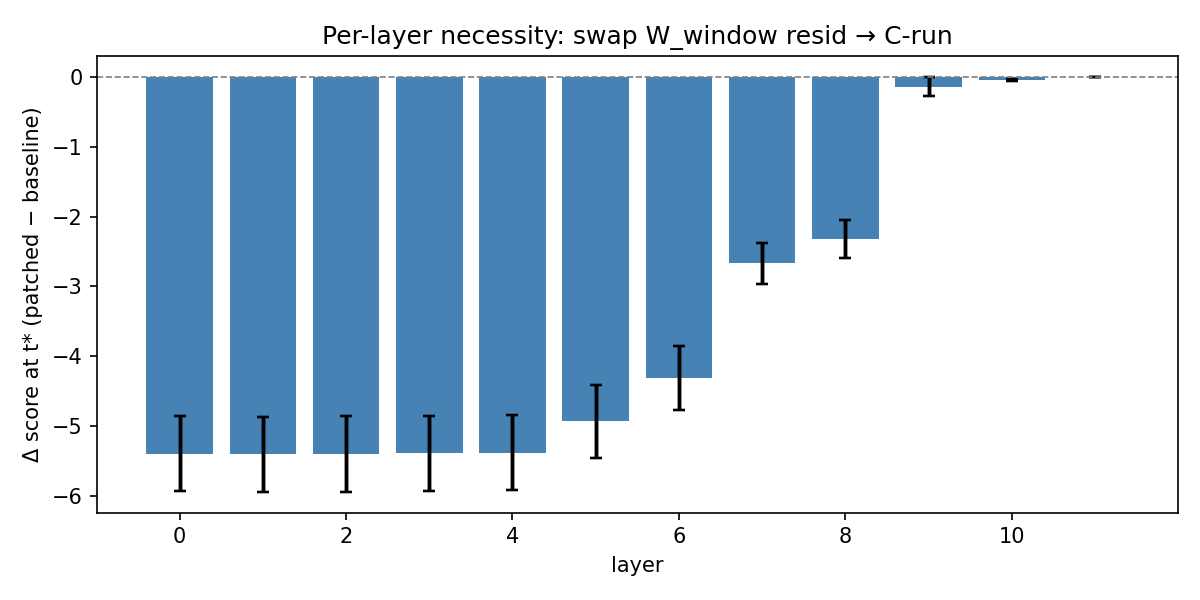

In [4]:
plot_layer_sweep(df, "per_layer_necessity.png")
plot_intervention_bars(summary, "main_interventions.png")
from IPython.display import Image
Image(filename=OUT_DIR / "per_layer_necessity.png")
